# Assignment 1: Understanding Generative and Discriminative Models Using MNIST
Name : Varshith Kumar R
Class : BCA
## Objective

The objective of this assignment is to understand the basic difference between a discriminative model and a generative model using the MNIST handwritten digit dataset.

In this assignment, only images of the digits **0 and 1** are used.

- A **Discriminative Model** is trained to classify an image as either 0 or 1.
- A **Generative Model** learns the patterns of the images and generates new examples.

The discriminative model used is **Logistic Regression**, while the generative model used is a simple **Autoencoder**.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images shape:", X_train.shape)
print("Testing images shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Testing images shape: (10000, 28, 28)


In [4]:
# Select only images of digits 0 and 1
train_mask = (y_train == 0) | (y_train == 1)
test_mask = (y_test == 0) | (y_test == 1)

X_train_01 = X_train[train_mask]
y_train_01 = y_train[train_mask]

X_test_01 = X_test[test_mask]
y_test_01 = y_test[test_mask]

print("Training images containing 0 and 1:", X_train_01.shape)
print("Testing images containing 0 and 1:", X_test_01.shape)

print("\nTraining class distribution:")
print("Digit 0:", np.sum(y_train_01 == 0))
print("Digit 1:", np.sum(y_train_01 == 1))

Training images containing 0 and 1: (12665, 28, 28)
Testing images containing 0 and 1: (2115, 28, 28)

Training class distribution:
Digit 0: 5923
Digit 1: 6742


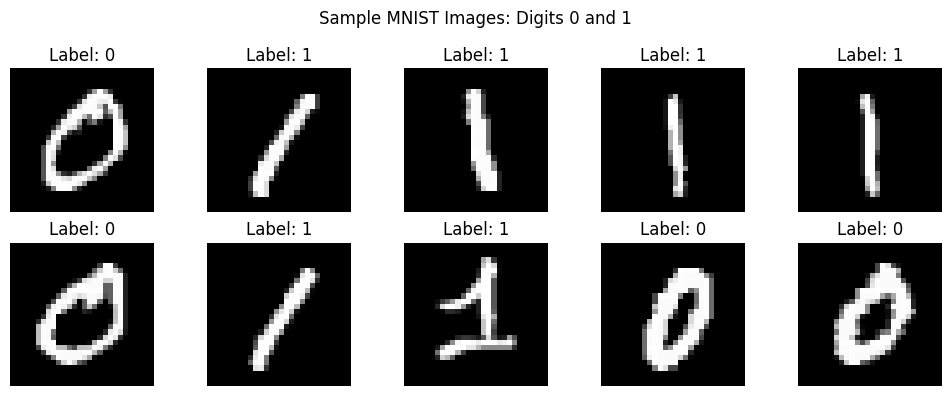

In [5]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_01[i], cmap='gray')
    plt.title(f"Label: {y_train_01[i]}")
    plt.axis('off')

plt.suptitle("Sample MNIST Images: Digits 0 and 1")
plt.tight_layout()
plt.show()

In [6]:
# Normalize pixel values
X_train_norm = X_train_01.astype("float32") / 255.0
X_test_norm = X_test_01.astype("float32") / 255.0

# Flatten 28x28 images into 784-dimensional vectors
X_train_flat = X_train_norm.reshape(len(X_train_norm), 784)
X_test_flat = X_test_norm.reshape(len(X_test_norm), 784)

print("Flattened training shape:", X_train_flat.shape)
print("Flattened testing shape:", X_test_flat.shape)

Flattened training shape: (12665, 784)
Flattened testing shape: (2115, 784)


In [7]:
# Create Logistic Regression model
discriminative_model = LogisticRegression(
    max_iter=1000,
    solver='lbfgs'
)

# Train the model
discriminative_model.fit(X_train_flat, y_train_01)

print("Discriminative model training completed!")

Discriminative model training completed!


In [8]:
# Make predictions
y_pred = discriminative_model.predict(X_test_flat)

# Calculate accuracy
accuracy = accuracy_score(y_test_01, y_pred)

print(f"Discriminative Model Accuracy: {accuracy * 100:.2f}%")

Discriminative Model Accuracy: 99.95%


In [9]:
print("Classification Report:\n")
print(classification_report(y_test_01, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      1.00      1.00      1135

    accuracy                           1.00      2115
   macro avg       1.00      1.00      1.00      2115
weighted avg       1.00      1.00      1.00      2115



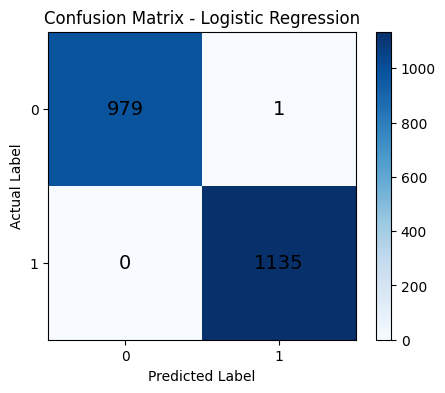

In [10]:
cm = confusion_matrix(y_test_01, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ['0', '1'])
plt.yticks([0, 1], ['0', '1'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha='center',
                 va='center',
                 fontsize=14)

plt.colorbar()
plt.show()

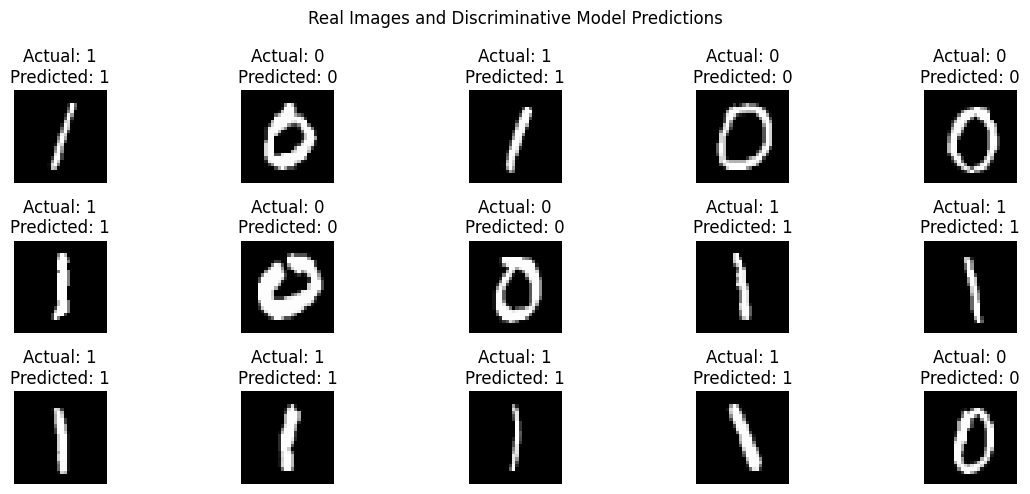

In [11]:
plt.figure(figsize=(12, 5))

for i in range(15):
    plt.subplot(3, 5, i + 1)

    plt.imshow(X_test_01[i], cmap='gray')

    actual = y_test_01[i]
    predicted = y_pred[i]

    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis('off')

plt.suptitle("Real Images and Discriminative Model Predictions")
plt.tight_layout()
plt.show()

## Generative Model - Autoencoder

An autoencoder learns to reconstruct input images.

The encoder compresses the 784-pixel image into a smaller latent representation, while the decoder reconstructs the image.

Unlike Logistic Regression, the autoencoder is not directly trained to predict the class label.

In [12]:
# Combine training and testing images for the autoencoder
X_all = np.concatenate((X_train_norm, X_test_norm), axis=0)

# Flatten images
X_all_flat = X_all.reshape(len(X_all), 784)

print("Autoencoder input shape:", X_all_flat.shape)

Autoencoder input shape: (14780, 784)


In [13]:
# Size of input image
input_dim = 784

# Size of latent representation
latent_dim = 32

# Encoder
input_image = Input(shape=(input_dim,))

encoded = Dense(128, activation='relu')(input_image)
encoded = Dense(64, activation='relu')(encoded)
latent = Dense(latent_dim, activation='relu')(encoded)

# Decoder
decoded = Dense(64, activation='relu')(latent)
decoded = Dense(128, activation='relu')(decoded)
output_image = Dense(784, activation='sigmoid')(decoded)

# Complete autoencoder
autoencoder = Model(input_image, output_image)

# Compile
autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = autoencoder.fit(
    X_all_flat,
    X_all_flat,
    epochs=10,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 0.3333 - val_loss: 0.1813
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.1618 - val_loss: 0.1442
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1343 - val_loss: 0.1257
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1212 - val_loss: 0.1153
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1143 - val_loss: 0.1110
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.1105 - val_loss: 0.1067
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.1053 - val_loss: 0.1015
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.1007 - val_loss: 0.0973
Epoch 9/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0968 - val_loss: 0.0940
Epoch 10/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0938 - val_loss: 0.0916


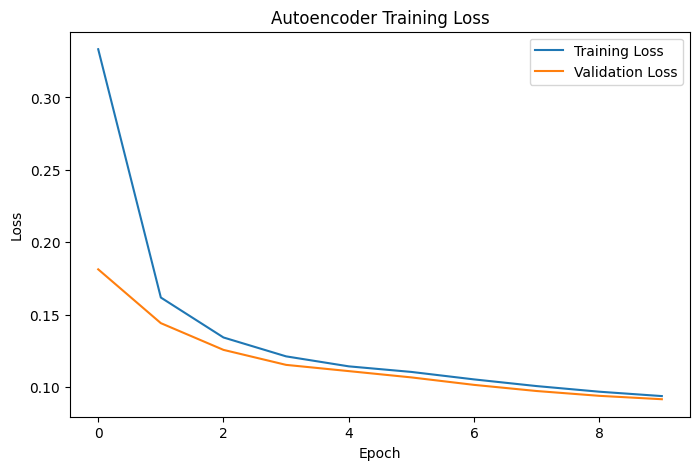

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step


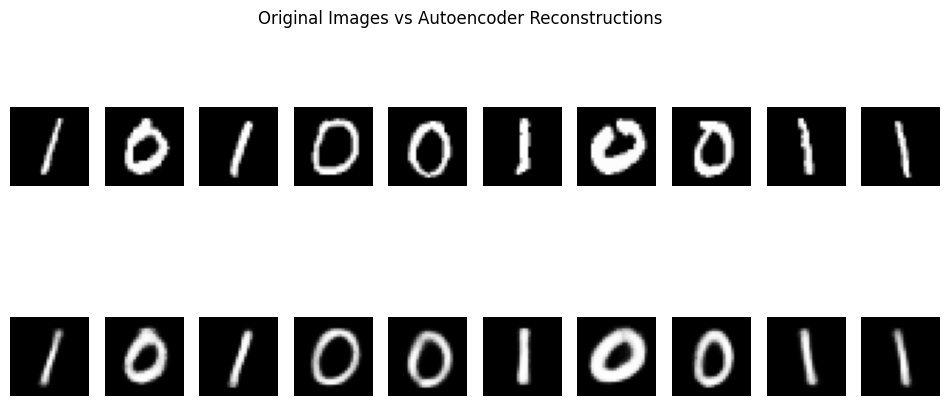

In [16]:
# Select some test images
sample_images = X_test_norm[:10].reshape(10, 784)

# Reconstruct images
reconstructed = autoencoder.predict(sample_images)

# Convert back to 28x28
reconstructed_images = reconstructed.reshape(10, 28, 28)

plt.figure(figsize=(12, 5))

for i in range(10):

    # Original
    plt.subplot(2, 10, i + 1)
    plt.imshow(X_test_norm[i], cmap='gray')
    plt.axis('off')

    # Reconstructed
    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructed_images[i], cmap='gray')
    plt.axis('off')

plt.suptitle("Original Images vs Autoencoder Reconstructions")
plt.show()

In [17]:
# Extract the decoder part of the autoencoder
decoder_input = Input(shape=(latent_dim,))

decoder_layer1 = autoencoder.layers[4](decoder_input)
decoder_layer2 = autoencoder.layers[5](decoder_layer1)
decoder_output = autoencoder.layers[6](decoder_layer2)

decoder = Model(decoder_input, decoder_output)

print("Decoder created successfully!")

Decoder created successfully!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


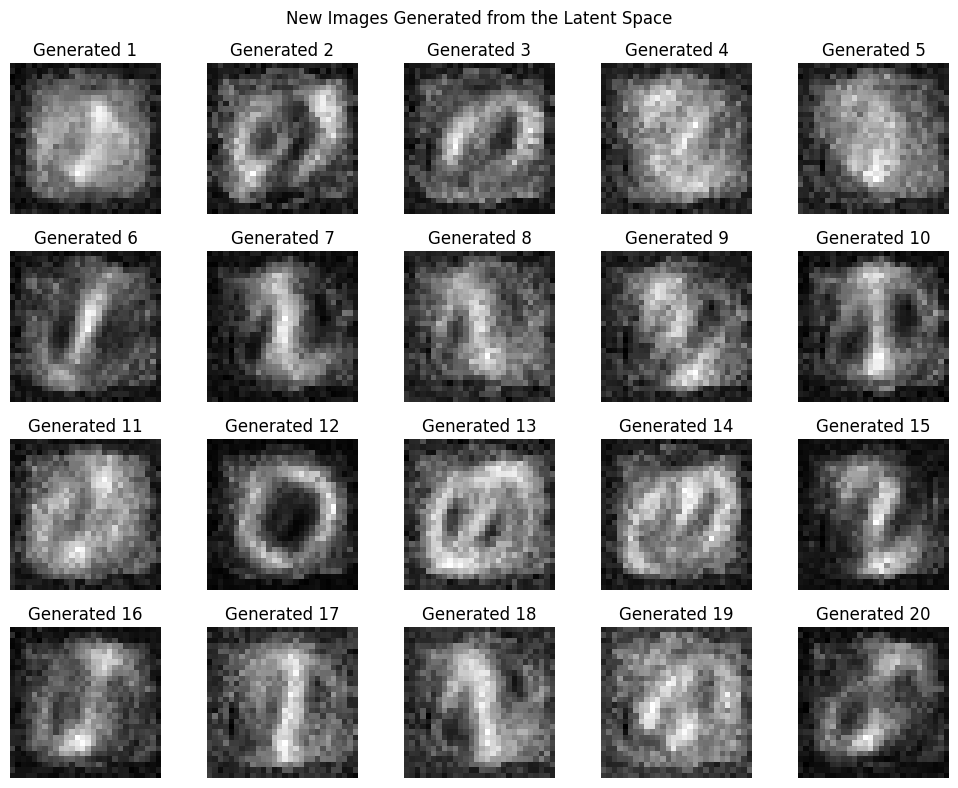

In [18]:
# Generate random latent vectors
np.random.seed(42)

random_latent_vectors = np.random.normal(
    size=(20, latent_dim)
)

# Generate new images
generated_images = decoder.predict(random_latent_vectors)

# Reshape to 28x28
generated_images = generated_images.reshape(20, 28, 28)

# Display generated images
plt.figure(figsize=(10, 8))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(generated_images[i], cmap='gray')
    plt.title(f"Generated {i+1}")
    plt.axis('off')

plt.suptitle("New Images Generated from the Latent Space")
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


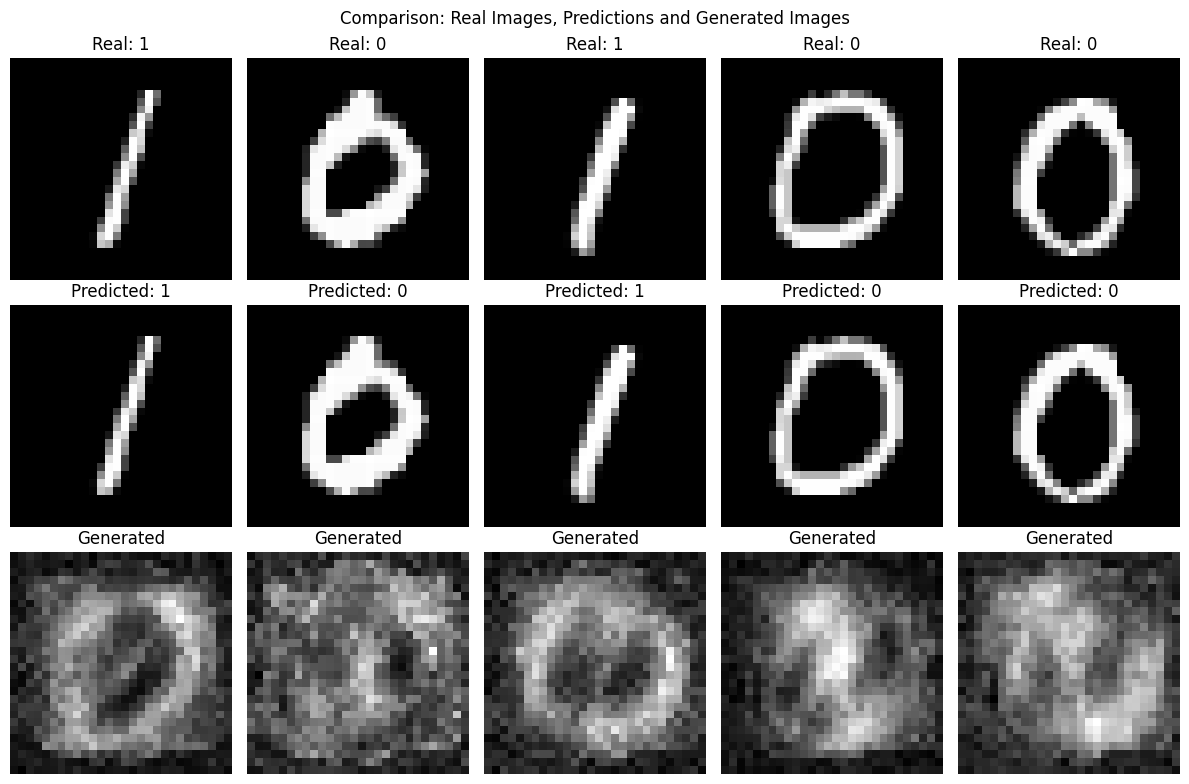

In [19]:
# Select 5 test images
n = 5

original = X_test_norm[:n]

# Predictions
predictions = y_pred[:n]

# Reconstruct
reconstructed = autoencoder.predict(
    original.reshape(n, 784)
).reshape(n, 28, 28)

# Generate 5 random images
random_latent = np.random.normal(size=(n, latent_dim))
generated = decoder.predict(random_latent).reshape(n, 28, 28)

plt.figure(figsize=(12, 8))

for i in range(n):

    # Original
    plt.subplot(3, n, i + 1)
    plt.imshow(original[i], cmap='gray')
    plt.title(f"Real: {y_test_01[i]}")
    plt.axis('off')

    # Prediction
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(original[i], cmap='gray')
    plt.title(f"Predicted: {predictions[i]}")
    plt.axis('off')

    # Generated
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(generated[i], cmap='gray')
    plt.title("Generated")
    plt.axis('off')

plt.suptitle("Comparison: Real Images, Predictions and Generated Images")
plt.tight_layout()
plt.show()

# Comparison of Discriminative and Generative Models

| Feature | Discriminative Model | Generative Model |
|---|---|---|
| Model Used | Logistic Regression | Autoencoder |
| Main Purpose | Classification | Learning image patterns |
| Input | MNIST image | MNIST image |
| Output | Digit 0 or 1 | Reconstructed/generated image |
| Learns | Decision boundary | Representation of the data |
| Uses Labels | Yes | No labels required |
| Can Generate Images | No | Yes |

## Written Reflection

The discriminative model learned the important pixel patterns that help distinguish between the digits 0 and 1 and used these patterns to create a decision boundary. The generative model learned the common visual patterns present in the digit images and compressed them into a smaller latent representation. Unlike the discriminative model, the autoencoder focuses on reconstructing images instead of directly predicting their labels. Therefore, the main difference is that the discriminative approach learns how to separate classes, while the generative approach learns the underlying structure of the data and can produce new examples.

# Conclusion

In this assignment, MNIST images containing only digits 0 and 1 were used to understand discriminative and generative learning.

Logistic Regression successfully classified the handwritten digits with high accuracy, demonstrating how a discriminative model learns a decision boundary between two classes.

The Autoencoder learned a compressed representation of the images and was able to reconstruct the handwritten digits. Random latent representations were also passed through the decoder to produce new digit-like images.

This experiment demonstrates the fundamental difference between learning a **decision boundary** and learning a **representation/data distribution**.